## Task 1: Predicting Grip-Loss Events in Collaborative Robots Using Machine Learning Techniques


In [1]:
# Imports libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# The plot to appear inside the notebook
%matplotlib inline  

# Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# Model Train, Evaluation & Results
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, average_precision_score
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer 
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [2]:
#import dataset
Robot_df = pd.read_excel('dataset_02052023.xlsx')

# Check the first 5 rows
Robot_df.head()

,Num,Timestamp,Current_J0,Temperature_T0,Current_J1,Temperature_J1,Current_J2,Temperature_J2,Current_J3,Temperature_J3,...,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5,Tool_current,cycle,Robot_ProtectiveStop,grip_lost
0,1,2022-10-26T08:17:21.847Z,0.109628,27.875,-2.024669,29.3750,-1.531442,29.3750,-0.998570,32.1250,...,2.955651e-01,-0.000490,0.001310,-0.132836,-0.007479,-0.152962,0.082732,1,0.0,False
1,2,2022-10-26T08:17:22.852Z,0.595605,27.875,-2.278456,29.3125,-0.866556,29.4375,-0.206097,32.1875,...,-7.391485e-30,-0.000304,0.002185,0.001668,-0.000767,0.000417,0.505895,1,0.0,False
2,3,2022-10-26T08:17:23.857Z,-0.229474,27.875,-2.800408,29.3125,-2.304336,29.4375,-0.351499,32.1250,...,1.369386e-01,0.007795,-2.535874,0.379867,0.000455,-0.496856,0.079420,1,0.0,False
3,4,2022-10-26T08:17:24.863Z,0.065053,27.875,-3.687768,29.3125,-1.217652,29.4375,-1.209115,32.1250,...,-9.030032e-02,-0.004911,-0.009096,-0.384196,0.018411,0.425559,0.083325,1,0.0,False
4,5,2022-10-26T08:17:25.877Z,0.884140,27.875,-2.938830,29.3750,-1.794076,29.4375,-2.356471,32.1875,...,1.268088e-01,0.005567,0.001138,-0.353284,0.014994,0.180989,0.086379,1,0.0,False


In [3]:
# Check the last five rows
Robot_df.tail()

,Num,Timestamp,Current_J0,Temperature_T0,Current_J1,Temperature_J1,Current_J2,Temperature_J2,Current_J3,Temperature_J3,...,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5,Tool_current,cycle,Robot_ProtectiveStop,grip_lost
7404,7405,2022-10-26T15:36:02.555Z,-0.109017,37.1875,-2.261695,40.3125,-1.082678,40.6875,-0.494714,43.375,...,0.0,0.0,0.0,0.0,0.0,0.0,0.080013,264,0.0,False
7405,7406,2022-10-26T15:36:03.562Z,-0.098536,37.1875,-2.251992,40.3125,-1.094420,40.6875,-0.515789,43.375,...,0.0,0.0,0.0,0.0,0.0,0.0,0.078740,264,0.0,False
7406,7407,2022-10-26T15:36:04.571Z,-0.121100,37.1875,-2.280791,40.2500,-1.121319,40.6875,-0.502406,43.375,...,0.0,0.0,0.0,0.0,0.0,0.0,0.091471,264,0.0,False
7407,7408,2022-10-26T15:36:05.572Z,-0.129370,37.1875,-2.269061,40.3125,-1.091610,40.6250,-0.491158,43.375,...,0.0,0.0,0.0,0.0,0.0,0.0,0.090026,264,0.0,False
7408,7409,2022-10-26T15:36:06.580Z,-0.134429,37.1250,-2.244449,40.3125,-1.098950,40.6875,-0.502397,43.375,...,0.0,0.0,0.0,0.0,0.0,0.0,0.089097,264,0.0,False


### Exploratory Data Analysis

In [4]:
# verify the columns present
Robot_df.columns

Index(['Num', 'Timestamp', 'Current_J0', 'Temperature_T0', 'Current_J1',
       'Temperature_J1', 'Current_J2', 'Temperature_J2', 'Current_J3',
       'Temperature_J3', 'Current_J4', 'Temperature_J4', 'Current_J5',
       'Temperature_J5', 'Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3',
       'Speed_J4', 'Speed_J5', 'Tool_current', 'cycle ',
       'Robot_ProtectiveStop', 'grip_lost'],
      dtype='str')

In [5]:
# Check number of column and rows
Robot_df.shape

(7409, 24)

In [6]:
# get more information about the data
Robot_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7409 entries, 0 to 7408
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Num                   7409 non-null   int64  
 1   Timestamp             7409 non-null   str    
 2   Current_J0            7363 non-null   float64
 3   Temperature_T0        7355 non-null   float64
 4   Current_J1            7355 non-null   float64
 5   Temperature_J1        7355 non-null   float64
 6   Current_J2            7355 non-null   float64
 7   Temperature_J2        7355 non-null   float64
 8   Current_J3            7355 non-null   float64
 9   Temperature_J3        7355 non-null   float64
 10  Current_J4            7355 non-null   float64
 11  Temperature_J4        7355 non-null   float64
 12  Current_J5            7355 non-null   float64
 13  Temperature_J5        7355 non-null   float64
 14  Speed_J0              7355 non-null   float64
 15  Speed_J1              7355 non-n

In [7]:
# Checking basic statistics of the dataset
Robot_df.describe()

,Num,Current_J0,Temperature_T0,Current_J1,Temperature_J1,Current_J2,Temperature_J2,Current_J3,Temperature_J3,Current_J4,...,Temperature_J5,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5,Tool_current,cycle,Robot_ProtectiveStop
count,7409.000000,7363.000000,7355.000000,7355.000000,7355.000000,7355.000000,7355.000000,7355.000000,7355.000000,7355.000000,...,7355.000000,7355.000000,7355.000000,7355.000000,7355.000000,7355.000000,7355.000000,7355.000000,7409.000000,7355.000000
mean,3705.000000,-0.048934,34.906781,-2.297936,37.659636,-1.199381,38.064064,-0.605312,40.936999,-0.022968,...,41.891094,0.001671,0.000061,0.003791,-0.004610,-0.000810,0.002880,0.109527,141.113241,0.037797
std,2138.938405,0.829395,2.762057,0.800450,3.247315,0.609984,3.311948,0.514937,3.182399,0.630789,...,3.680003,0.148826,0.049370,0.729422,0.359999,0.038436,0.313953,0.078832,80.542340,0.190719
min,1.000000,-6.247756,27.812500,-5.808734,29.312500,-4.171966,29.375000,-3.333102,32.125000,-4.738406,...,32.000000,-0.656331,-0.330833,-2.733091,-1.271460,-0.226233,-1.629721,0.020180,1.000000,0.000000
25%,1853.000000,-0.195026,33.000000,-2.664919,35.375000,-1.552803,35.750000,-0.830933,38.937500,-0.125809,...,39.500000,-0.000483,-0.000659,-0.004100,-0.005365,-0.000120,-0.000803,0.082387,68.000000,0.000000
50%,3705.000000,-0.080830,36.500000,-2.236342,39.687500,-1.077137,40.187500,-0.571190,43.062500,-0.012325,...,44.375000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.085192,154.000000,0.000000
75%,5557.000000,0.095959,37.062500,-1.778334,40.125000,-0.838721,40.437500,-0.388398,43.125000,0.086098,...,44.500000,0.002115,0.000540,0.000205,0.009912,0.000066,0.012924,0.089518,218.000000,0.000000
max,7409.000000,6.806938,37.250000,1.083596,40.500000,2.464940,40.937500,2.270268,43.437500,4.089389,...,44.937500,0.791929,0.615526,2.679848,1.363093,0.193914,1.378015,0.602054,264.000000,1.000000


In [8]:
# check for missing values
# Missing values present in some columns
Robot_df.isna().sum()

Num                      0
Timestamp                0
Current_J0              46
Temperature_T0          54
Current_J1              54
Temperature_J1          54
Current_J2              54
Temperature_J2          54
Current_J3              54
Temperature_J3          54
Current_J4              54
Temperature_J4          54
Current_J5              54
Temperature_J5          54
Speed_J0                54
Speed_J1                54
Speed_J2                54
Speed_J3                54
Speed_J4                54
Speed_J5                54
Tool_current            54
cycle                    0
Robot_ProtectiveStop    54
grip_lost                0
dtype: int64

#### Check class distribution of Target variable 

Class distribution (Counts):
 grip_lost
False    7166
True      243
Name: count, dtype: int64

Class distribution (%):
 grip_lost
False    96.72
True      3.28
Name: count, dtype: float64


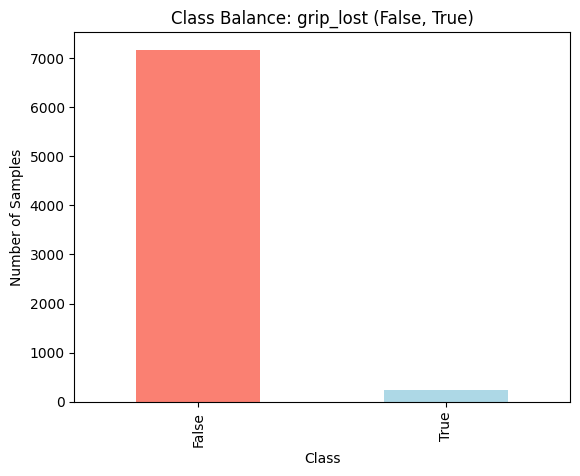

In [9]:
# Count values for target variable
class_counts = Robot_df['grip_lost'].value_counts()
class_perc   = (class_counts / len(Robot_df) * 100).round(2)

# Print counts and percentages
print("Class distribution (Counts):\n", class_counts)
print("\nClass distribution (%):\n", class_perc)

# Plot bar chart
class_counts.plot( kind="bar", title="Class Balance: grip_lost (False, True)", color=['salmon', 'lightblue'])
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()


In [10]:
# Convert target column 'grip_lost' from Boolean (True/False) to numeric (1/0)
# This ensures compatibility with machine learning models that require numerical inputs.
Robot_df["grip_lost"] = Robot_df["grip_lost"].replace(['False', 'True'], [0, 1]).astype(int)
Robot_df.head()

,Num,Timestamp,Current_J0,Temperature_T0,Current_J1,Temperature_J1,Current_J2,Temperature_J2,Current_J3,Temperature_J3,...,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5,Tool_current,cycle,Robot_ProtectiveStop,grip_lost
0,1,2022-10-26T08:17:21.847Z,0.109628,27.875,-2.024669,29.3750,-1.531442,29.3750,-0.998570,32.1250,...,2.955651e-01,-0.000490,0.001310,-0.132836,-0.007479,-0.152962,0.082732,1,0.0,0
1,2,2022-10-26T08:17:22.852Z,0.595605,27.875,-2.278456,29.3125,-0.866556,29.4375,-0.206097,32.1875,...,-7.391485e-30,-0.000304,0.002185,0.001668,-0.000767,0.000417,0.505895,1,0.0,0
2,3,2022-10-26T08:17:23.857Z,-0.229474,27.875,-2.800408,29.3125,-2.304336,29.4375,-0.351499,32.1250,...,1.369386e-01,0.007795,-2.535874,0.379867,0.000455,-0.496856,0.079420,1,0.0,0
3,4,2022-10-26T08:17:24.863Z,0.065053,27.875,-3.687768,29.3125,-1.217652,29.4375,-1.209115,32.1250,...,-9.030032e-02,-0.004911,-0.009096,-0.384196,0.018411,0.425559,0.083325,1,0.0,0
4,5,2022-10-26T08:17:25.877Z,0.884140,27.875,-2.938830,29.3750,-1.794076,29.4375,-2.356471,32.1875,...,1.268088e-01,0.005567,0.001138,-0.353284,0.014994,0.180989,0.086379,1,0.0,0


#### Correlation matrix for features

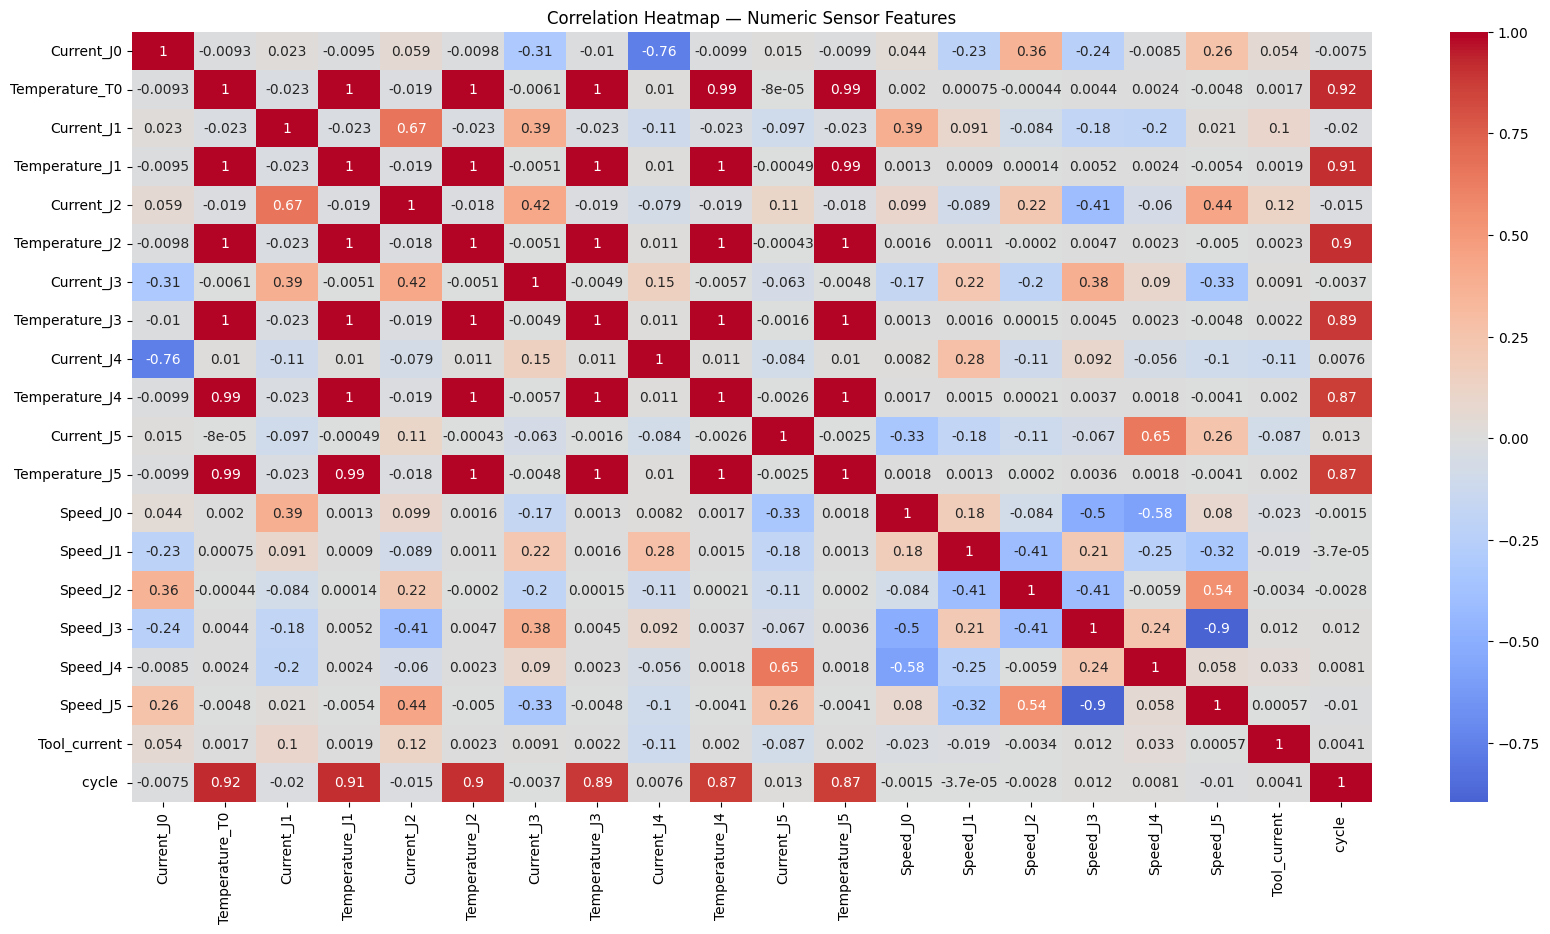

In [11]:
# Select only numeric columns
Num_df = Robot_df.iloc[:, 2:22]
num_cols_for_eda = Num_df.columns.tolist()

# Visualize correlation between numeric features
plt.figure(figsize=(20, 10))
sns.heatmap(Num_df.corr(), cmap='coolwarm', annot=True, center=0)
plt.title("Correlation Heatmap — Numeric Sensor Features")
plt.show()

#### Checking the skewness of the data

In [12]:
# Skewness helps identify asymmetry in feature distributions.
# Values close to 0 indicate a roughly normal distribution.
# Positive skew (>0) = right tail longer (more small values)
# Negative skew (<0) = left tail longer (more large values)
Robot_df.skew(numeric_only=True)


Num                     0.000000
Current_J0              0.033888
Temperature_T0         -1.006934
Current_J1             -0.529337
Temperature_J1         -1.012741
Current_J2             -0.111922
Temperature_J2         -1.048102
Current_J3              0.380319
Temperature_J3         -1.143470
Current_J4              0.125941
Temperature_J4         -1.171061
Current_J5             -0.130040
Temperature_J5         -1.085168
Speed_J0                0.200484
Speed_J1                2.004742
Speed_J2                0.083913
Speed_J3               -0.002745
Speed_J4               -0.065965
Speed_J5               -0.197421
Tool_current            3.910756
cycle                  -0.142791
Robot_ProtectiveStop    4.848268
grip_lost               5.247358
dtype: float64

#### Visualizing the distribution of the most skewed features

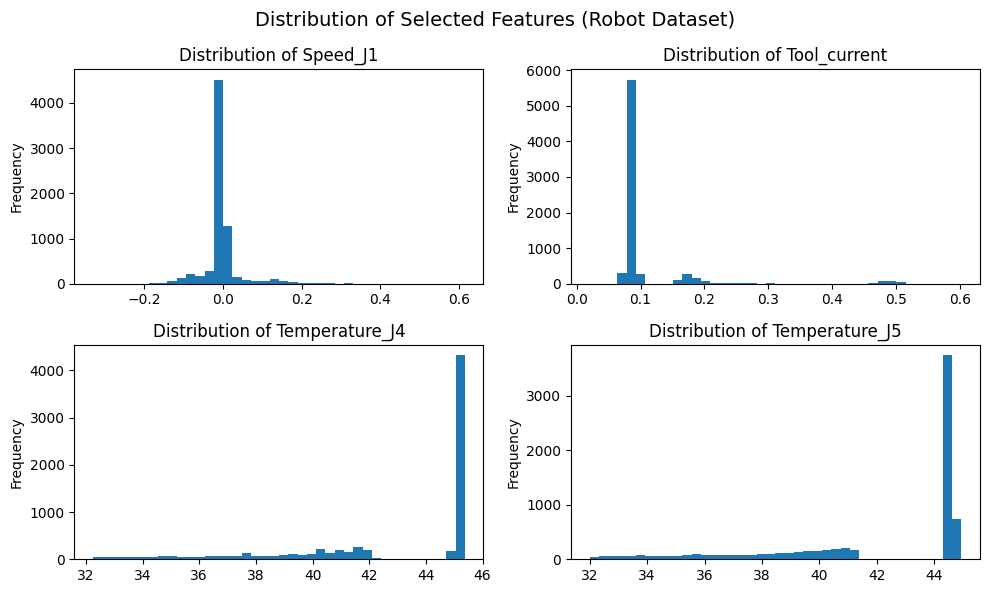

In [13]:
# This helps confirm which features deviate from normality.
# Features plotted: Speed_J1, Tool_current, Temperature_J4, Temperature_J5
# These were selected based on high skewness from the previous step.
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

Robot_df['Speed_J1'].plot(kind='hist', bins=40, ax=axes[0,0], title='Distribution of Speed_J1')
Robot_df['Tool_current'].plot(kind='hist', bins=40, ax=axes[0,1], title='Distribution of Tool_current')
Robot_df['Temperature_J4'].plot(kind='hist', bins=40, ax=axes[1,0], title='Distribution of Temperature_J4')
Robot_df['Temperature_J5'].plot(kind='hist', bins=40, ax=axes[1,1], title='Distribution of Temperature_J5')

plt.suptitle('Distribution of Selected Features (Robot Dataset)', size=14)
plt.tight_layout()
plt.show()


#### Boxplots of Key Features vs Target (Grip Lost)

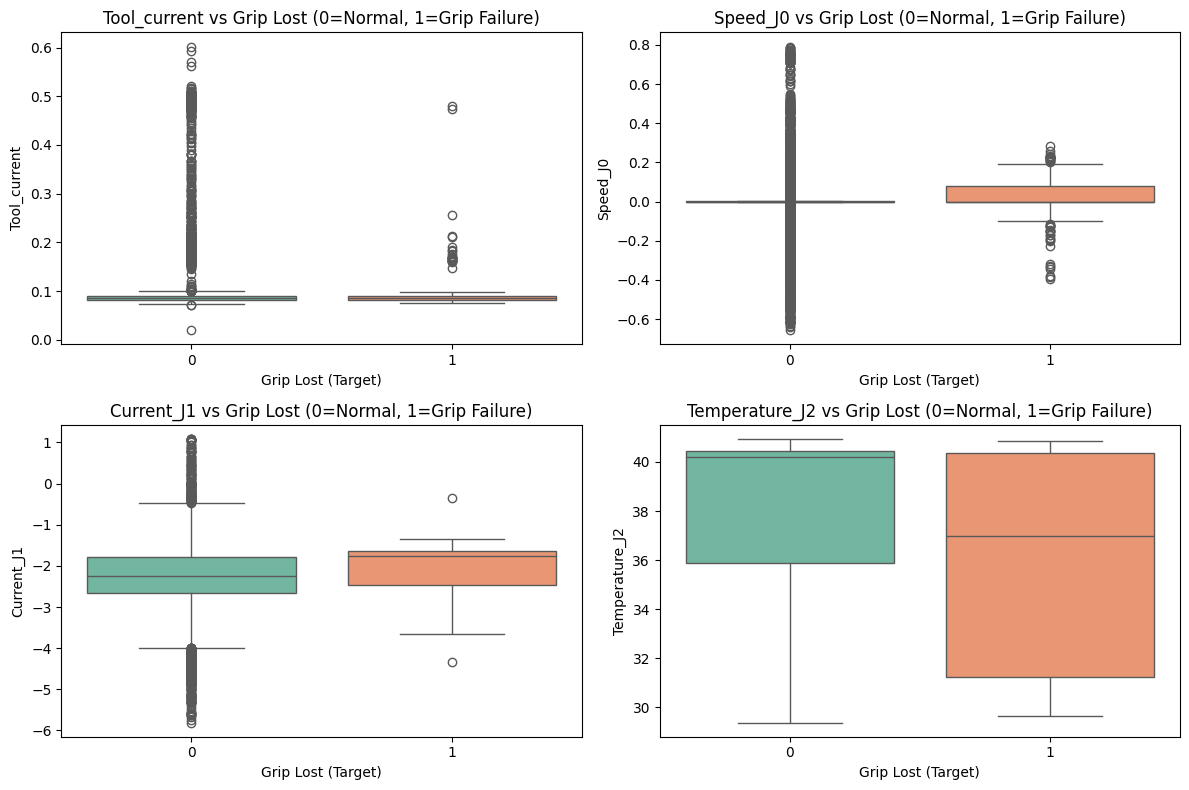

In [14]:
# Visualize key numeric features against the target variable
# Helps compare distribution differences between normal (0) and grip failure (1)
# across key numeric features.

features = ["Tool_current", "Speed_J0", "Current_J1", "Temperature_J2"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()  # flatten 2x2 array of axes into 1D for easy iteration

for i, col in enumerate(features):
    if col in Robot_df.columns:
        sns.boxplot(
            data=Robot_df,
            x="grip_lost",               # target variable on X-axis
            y=col,                       # feature being compared
            hue="grip_lost",
            palette="Set2",
            legend=False,
            ax=axes[i]
        )
        axes[i].set_title(f"{col} vs Grip Lost (0=Normal, 1=Grip Failure)")
        axes[i].set_xlabel("Grip Lost (Target)")
        axes[i].set_ylabel(col)

# Adjust layout so titles don’t overlap
plt.tight_layout()
plt.show()


####  KDE plots for key feature

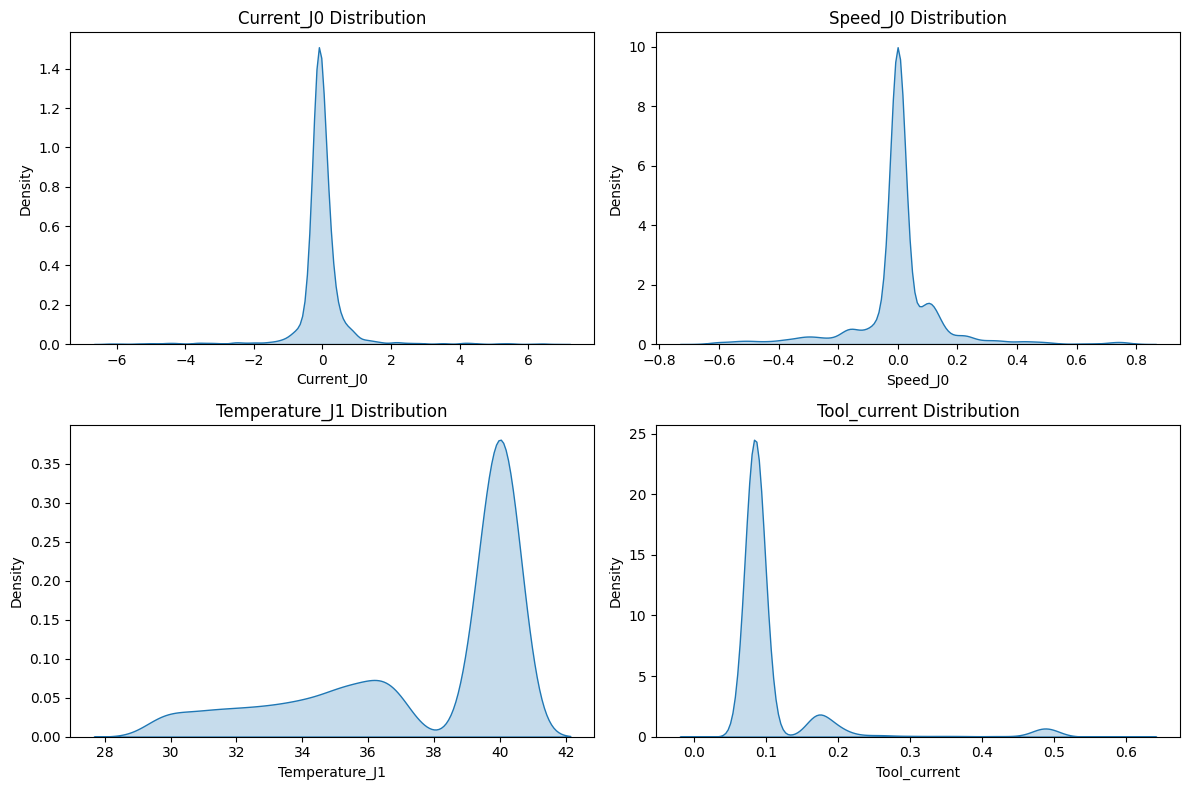

In [15]:
# Representative KDE plots for each feature group

import matplotlib.pyplot as plt
import seaborn as sns

# Representative features
rep_current = "Current_J0"
rep_speed   = "Speed_J0"
rep_temp    = "Temperature_J1"
rep_tool    = "Tool_current"

fig, axes = plt.subplots(2, 2, figsize=(12,8))

# Current
sns.kdeplot(data=Robot_df[rep_current], fill=True, ax=axes[0,0])
axes[0,0].set_title(f"{rep_current} Distribution")

# Speed
sns.kdeplot(data=Robot_df[rep_speed], fill=True, ax=axes[0,1])
axes[0,1].set_title(f"{rep_speed} Distribution")

# Temperature
sns.kdeplot(data=Robot_df[rep_temp], fill=True, ax=axes[1,0])
axes[1,0].set_title(f"{rep_temp} Distribution")

# Tool Current
sns.kdeplot(data=Robot_df[rep_tool], fill=True, ax=axes[1,1])
axes[1,1].set_title(f"{rep_tool} Distribution")

plt.tight_layout()
plt.show()

#### Identify Non-features, target variable and split dataset

In [16]:
# Identify non-feature columns
# These columns are identifiers or unrelated to prediction.
# - 'Robot_ProtectiveStop' is a secondary label not needed here.
# - 'Num' and 'Timestamp' are metadata or sequence identifiers.
# They don’t contribute to predicting grip loss, so we exclude them.
NON_FEATURES = [col for col in ["Robot_ProtectiveStop", "Num", "Timestamp"] if col in Robot_df.columns]

# Define target variable and feature matrix
TARGET = "grip_lost"  # The binary target (0 = normal grip, 1 = grip failure)

# Split data into X (features) and y (target)
X = Robot_df.drop(columns=NON_FEATURES + [TARGET])  # all predictors
y = Robot_df[TARGET]  # target label

# Split into training and test sets (80/20)
# StratifiedShuffleSplit ensures both sets maintain the same ratio of
# normal (0) vs. grip loss (1) events, preventing imbalance bias.
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(X, y))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


#### Feature reduction

In [17]:
# Feature reduction using correlation filter
# Purpose:
# - Identify and remove highly correlated features (r > 0.95)
# - Reduce redundancy and prevent overfitting in the model

# Compute absolute correlation matrix for training features
corr_matrix = X_train.corr().abs()

# Select only the upper triangle of the matrix to avoid duplicate checks
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identify columns where correlation exceeds 0.95
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
print("Dropped features due to high correlation:", to_drop)

# Drop redundant features from both training and test sets
X_train_reduced = X_train.drop(columns=to_drop)
X_test_reduced = X_test.drop(columns=to_drop)


Dropped features due to high correlation: ['Temperature_J1', 'Temperature_J2', 'Temperature_J3', 'Temperature_J4', 'Temperature_J5']


#### Build Pipeline Function

In [18]:
def build_pipeline(model):
    """
    Create a full ML pipeline for imbalanced classification:
      1. SimpleImputer: fill missing values with median
      2. MinMaxScaler: scale all features to [0,1]
      3. SMOTE: oversample minority class (training only)
      4. Classifier: RF or XGB

    Returns:
        ImbPipeline object
    """
    pipe = ImbPipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  MinMaxScaler()),
        ("smote",   SMOTE(random_state=42)),
        ("classifier", model)
    ])
    return pipe

#### Evaluation Function

In [19]:
def EvaluateModel(model, X_test, y_test, y_pred, model_name, hyper="NO"):
    """
    Compute classification metrics and return one-row DataFrame.
    Also prints accuracy immediately after prediction.
    """
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    try:
          # Predict probabilities for ROC-AUC if available
        auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    except:
        auc = float("nan")
    
    # Print accuracy for immediate feedback
    print(f"{model_name}: Accuracy - {acc:.6f}")
    
    # Compute standard metrics
    row = pd.DataFrame([{"Classifier": model_name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1, "AUC_Score": auc,
                         "Hyperparameters": hyper}])
    return row


#### Baseline Model Training Function (returns both metrics and fitted pipelines)

In [20]:
# Create the function
def run_models_return_pipes(X_train, X_test, y_train, y_test, label="AllFeatures"):
    
     # Define baseline classifiers
    models = {
        "RF": RandomForestClassifier(random_state=42),
        "XGB": XGBClassifier(objective="binary:logistic", eval_metric="auc", tree_method="hist", random_state=42)}

    results = []
    pipes = {}

    # Loop through classifiers
    for name, model in models.items():
        pipe = build_pipeline(model)       # create pipeline with preprocessing
        pipe.fit(X_train, y_train)         # train on training data
        y_pred = pipe.predict(X_test)      # predict on test data

        # Store pipeline for later lookup
        pipes[f"{name}_{label}"] = pipe

        # Evaluate and store metrics
        row = EvaluateModel(model=pipe, X_test=X_test, y_test=y_test, y_pred=y_pred, model_name=f"{name}_{label}", hyper="NO")
        results.append(row)

    return pd.concat(results, ignore_index=True), pipes

#### Run Baseline Experiments

In [21]:
# Run baseline experiments
results_all, all_pipes_all = run_models_return_pipes(X_train, X_test, y_train, y_test, label="AllFeatures")
results_red, all_pipes_red = run_models_return_pipes(X_train_reduced, X_test_reduced, y_train, y_test, label="ReducedFeatures")

# Combine metrics and pipelines
baseline_df = pd.concat([results_all, results_red], ignore_index=True)
baseline_pipes = {**all_pipes_all, **all_pipes_red}

# Order columns exactly
baseline_df = baseline_df[["Classifier","Accuracy","Precision","Recall","F1-Score","AUC_Score","Hyperparameters"]]
baseline_df = baseline_df.round(6)

# Print Baseline Result
print("\n-- Baseline Model Comparison --")
display(baseline_df.style.hide(axis='index'))


RF_AllFeatures: Accuracy - 0.966262
XGB_AllFeatures: Accuracy - 0.974359
RF_ReducedFeatures: Accuracy - 0.965587
XGB_ReducedFeatures: Accuracy - 0.958839

-- Baseline Model Comparison --


Classifier,Accuracy,Precision,Recall,F1-Score,AUC_Score,Hyperparameters
RF_AllFeatures,0.966262,0.491525,0.591837,0.537037,0.928279,NO
XGB_AllFeatures,0.974359,0.617021,0.591837,0.604167,0.958999,NO
RF_ReducedFeatures,0.965587,0.483871,0.612245,0.540541,0.941830,NO
XGB_ReducedFeatures,0.958839,0.411765,0.571429,0.478632,0.945355,NO


## Hyperparameter Tuning

In [22]:
# Stratified K-Fold CV setup for hyperparameter tuning
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

####  Random Forest Hyperparameter Tuning (Reduced Features)

In [23]:
# Build a full pipeline for RF (with imputer, scaler, SMOTE, classifier)
rf_pipe = build_pipeline(RandomForestClassifier(random_state=42))

# Define a moderate hyperparameter grid for tuning
# - n_estimators: number of trees
# - max_depth: maximum depth of each tree
rf_param_grid = {
    "classifier__n_estimators": [300, 500],
    "classifier__max_depth": [None, 8, 12]
}

# Setup GridSearchCV to find the best combination
rf_gs = GridSearchCV(estimator=rf_pipe, param_grid=rf_param_grid, scoring="f1", cv=cv, n_jobs=-1, verbose=1, return_train_score=True)

# Fit GridSearchCV on the reduced training data
rf_gs.fit(X_train_reduced, y_train)

# Print best hyperparameters and CV F1-score
print("\nBest RF params:", rf_gs.best_params_)
print("Best RF mean CV F1:", round(rf_gs.best_score_, 3))

# Get the best RF pipeline from GridSearchCV
best_rf = rf_gs.best_estimator_

# Predict on the REDUCED test set using the tuned RF
y_pred_rf = best_rf.predict(X_test_reduced)

# Evaluate tuned RF using the EvaluateModel function
rf_tuned_row = EvaluateModel(
    model=best_rf,               # fitted pipeline
    X_test=X_test_reduced,       # test features
    y_test=y_test,               # true labels
    y_pred=y_pred_rf,            # predicted labels
    model_name="RF_ReducedFeatures_Tuned",
    hyper="YES"                  # indicate this is a tuned model
)

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best RF params: {'classifier__max_depth': None, 'classifier__n_estimators': 500}
Best RF mean CV F1: 0.498
RF_ReducedFeatures_Tuned: Accuracy - 0.965587


####  XGBoost Hyperparameter Tuning (All Features)

In [24]:
# Build a pipeline for XGBoost classifier
xgb_pipe = build_pipeline(
    XGBClassifier(
        objective="binary:logistic",  eval_metric="auc",  tree_method="hist", random_state=42)
)

# Define hyperparameter grid for XGB
# - n_estimators: number of trees
# - max_depth: maximum depth per tree
xgb_param_grid = {
    "classifier__n_estimators": [300, 500],
    "classifier__max_depth": [3, 5, 7]
}

# Setup GridSearchCV for XGB
xgb_gs = GridSearchCV(estimator=xgb_pipe, param_grid=xgb_param_grid, scoring="f1", cv=cv, n_jobs=-1, verbose=1,      return_train_score=True)

# Step 4: Fit GridSearchCV on ALL training features
xgb_gs.fit(X_train, y_train)

# Step 5: Print best hyperparameters and CV F1-score
print("\nBest XGB params:", xgb_gs.best_params_)
print("Best XGB mean CV F1:", round(xgb_gs.best_score_, 3))

# Step 6: Retrieve best XGB pipeline
best_xgb = xgb_gs.best_estimator_

# Step 7: Predict on ALL-feature test set
y_pred_xgb = best_xgb.predict(X_test)

# Step 8: Evaluate tuned XGB using the EvaluateModel function
xgb_tuned_row = EvaluateModel(model=best_xgb, X_test=X_test, y_test=y_test, y_pred=y_pred_xgb, model_name="XGB_AllFeatures_Tuned", hyper="YES")


Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best XGB params: {'classifier__max_depth': 7, 'classifier__n_estimators': 300}
Best XGB mean CV F1: 0.508
XGB_AllFeatures_Tuned: Accuracy - 0.975034


#### Combine Baseline + Tuned Results and Pipelines

In [25]:
# Combine model results and pipelines
tuned_df = pd.concat([rf_tuned_row, xgb_tuned_row], ignore_index=True)
final_results_df = pd.concat([baseline_df, tuned_df], ignore_index=True)

# Combine pipelines
model_lookup = {**baseline_pipes, 
                "RF_ReducedFeatures_Tuned": best_rf,
                "XGB_AllFeatures_Tuned": best_xgb}

# Order columns
final_results_df = final_results_df[["Classifier","Accuracy","Precision","Recall","F1-Score","AUC_Score","Hyperparameters"]]
final_results_df = final_results_df.round(6)

# Print final result
print("\n-- Final Results Table --")
display(final_results_df.style.hide(axis='index'))



-- Final Results Table --


Classifier,Accuracy,Precision,Recall,F1-Score,AUC_Score,Hyperparameters
RF_AllFeatures,0.966262,0.491525,0.591837,0.537037,0.928279,NO
XGB_AllFeatures,0.974359,0.617021,0.591837,0.604167,0.958999,NO
RF_ReducedFeatures,0.965587,0.483871,0.612245,0.540541,0.941830,NO
XGB_ReducedFeatures,0.958839,0.411765,0.571429,0.478632,0.945355,NO
RF_ReducedFeatures_Tuned,0.965587,0.483871,0.612245,0.540541,0.944586,YES
XGB_AllFeatures_Tuned,0.975034,0.636364,0.571429,0.602151,0.963442,YES


### Select Best Model Across All Models

In [26]:
# Select Best Model Across All Models
best_idx = final_results_df["F1-Score"].idxmax()
best_model_name = final_results_df.loc[best_idx, "Classifier"]
print("\nBest model across all models (F1-score):", best_model_name)

best_model = model_lookup.get(best_model_name)
if best_model is None:
    raise ValueError(f"No fitted pipeline found for {best_model_name}")

# Choose corresponding test set
X_t = X_test_reduced if "Reduced" in best_model_name else X_test
y_pred_best = best_model.predict(X_t)


Best model across all models (F1-score): XGB_AllFeatures


#### Display the full metrics of the best model

In [27]:
# Display the full metrics
# As a Series (vertical listing)
best_model_row = final_results_df.loc[best_idx]
print("\nBest model based on F1-Score :\n")
print(best_model_row)


Best model based on F1-Score :

Classifier         XGB_AllFeatures
Accuracy                  0.974359
Precision                 0.617021
Recall                    0.591837
F1-Score                  0.604167
AUC_Score                 0.958999
Hyperparameters                 NO
Name: 1, dtype: object


###  Graphical Comparison of Metrics Across All Models

<Figure size 1200x600 with 0 Axes>

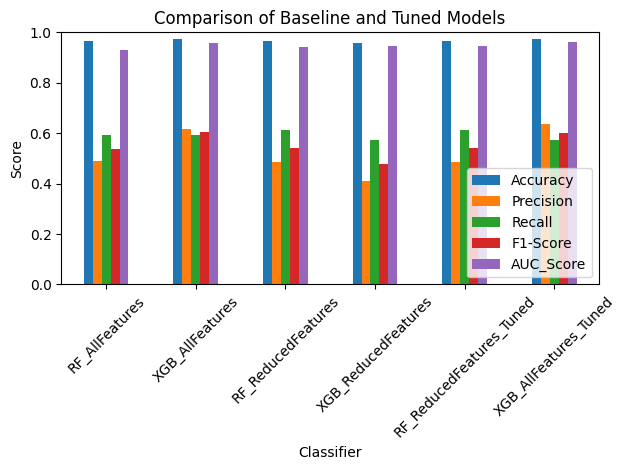

In [28]:
# Metrics Across All Models
metrics_to_plot = ["Accuracy","Precision","Recall","F1-Score","AUC_Score"]

plt.figure(figsize=(12,6))
final_results_df.set_index("Classifier")[metrics_to_plot].plot(kind='bar', rot=45)
plt.title("Comparison of Baseline and Tuned Models")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


#### Metric Comparision Plot

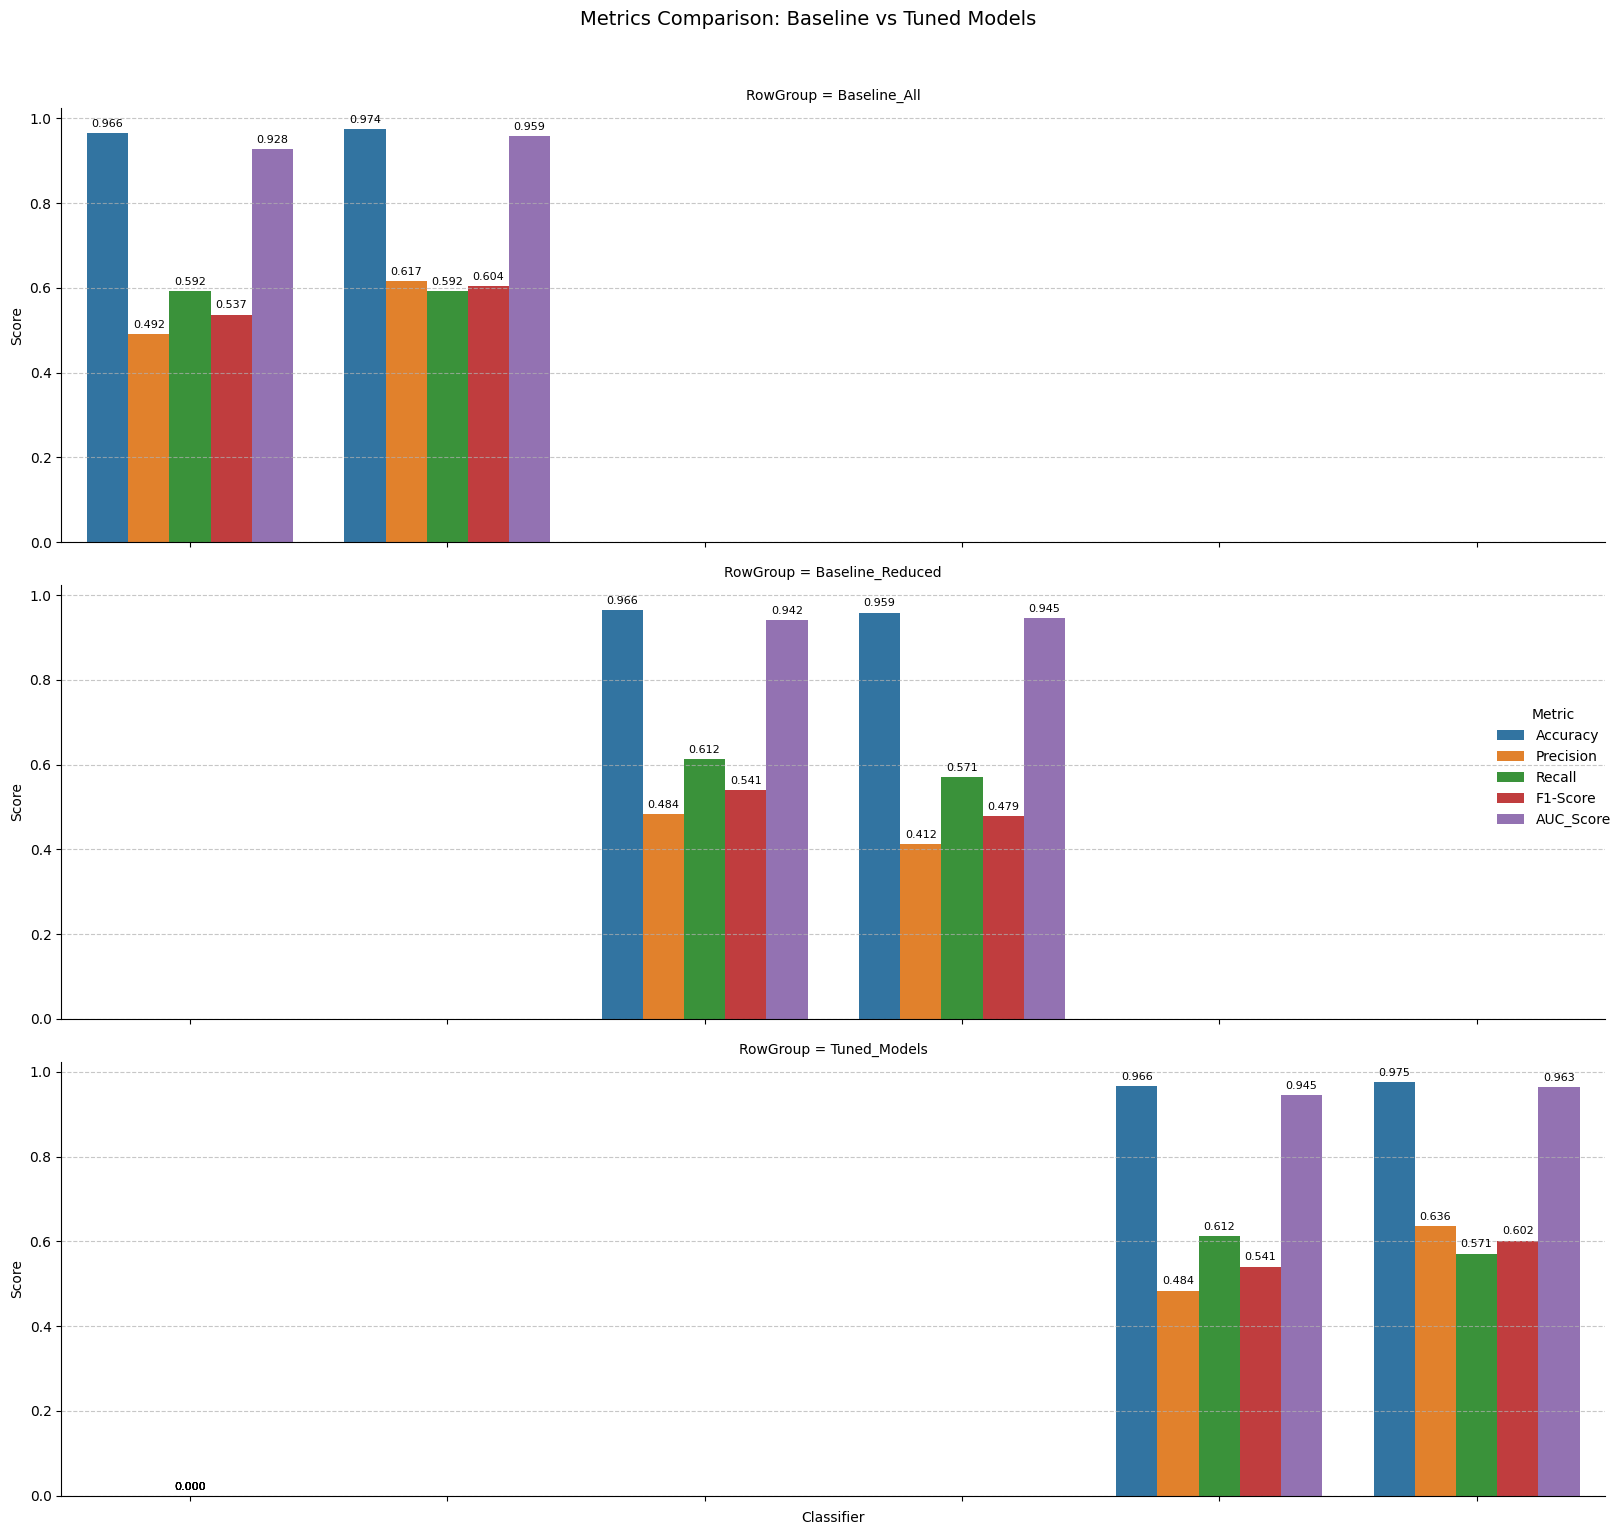

In [29]:
# Prepare row grouping (3 rows: Baseline All, Baseline Reduced, Tuned)
plot_df = final_results_df.copy()
plot_df["RowGroup"] = plot_df.apply(
    lambda r: "Baseline_All" if r.Hyperparameters=="NO" and "AllFeatures" in r.Classifier
              else "Baseline_Reduced" if r.Hyperparameters=="NO"
              else "Tuned_Models",
    axis=1
)

# Melt metrics for plotting
plot_df = plot_df.melt(
    id_vars=["Classifier","RowGroup"],
    value_vars=["Accuracy","Precision","Recall","F1-Score","AUC_Score"],
    var_name="Metric",
    value_name="Score"
)

# Create catplot with wider spacing and distinct colors
g = sns.catplot(data=plot_df, kind="bar", x="Classifier", y="Score", hue="Metric", row="RowGroup", palette="tab10",  height=5, aspect=3, 
    dodge=True, errorbar=None)

# Rotate x-axis labels for readability
g.set_xticklabels(rotation=45, ha="right")

# Add numeric labels on bars
for ax in g.axes.flat:
    # Add horizontal gridlines
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    
    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():.3f}",
            (p.get_x() + p.get_width()/2., p.get_height()),
            ha="center", va="bottom",
            fontsize=8, xytext=(0,3),
            textcoords="offset points"
        )

# Add title and adjust layout
g.fig.suptitle("Metrics Comparison: Baseline vs Tuned Models", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

#### Confusion Matrix Visualization

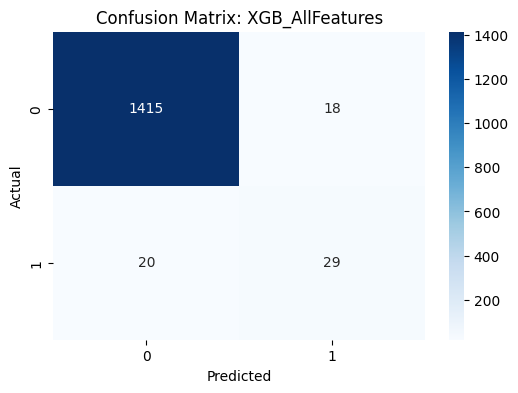

In [30]:
# Confusion Matrix 
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Classification Report

In [31]:
# Classification Report
print("\nClassification Report for Best Model:")
print(classification_report(y_test, y_pred_best))



Classification Report for Best Model:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1433
           1       0.62      0.59      0.60        49

    accuracy                           0.97      1482
   macro avg       0.80      0.79      0.80      1482
weighted avg       0.97      0.97      0.97      1482

